# Exoplanet Detection Bias
This project investigates whether currently known exoplanets represent a true sample of planetary systems or whether detection methods preferentially discover planets that are easier to observe.

Using observational data from the [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/), this analysis compares transit and non-transit detection methods across:

* Orbital period
* Planet mass
* Planet radius
* Stellar temperature
* Distance to host stars
* Discovery trends over time

To examine how observational bias shapes our current understanding of exoplanet populations, the project combines:

* Statistical hypothesis testing
* Exploratory data analysis (EDA)
* Logarithmic scaling analysis
* Distributional comparisons
* Trend modelling

## Data Source
This project makes use of the specific [Planetary Systems Composite Table from the NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PSCompPars), which contains confirmed exoplanet and host-star parameters compiled from multiple detection surveys and observational studies.

The dataset was accessed in May 2026 and features planetary, stellar, and orbital characteristics used throughout this analysis.

In [1]:
# Imports and Reproducibility:
from google.colab import files

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    ks_2samp,
    mannwhitneyu,
    spearmanr,
    linregress
)

from scipy.ndimage import gaussian_filter

from matplotlib.ticker import (
    LogLocator,
    FixedLocator,
    FuncFormatter,
    NullFormatter
)

from matplotlib.lines import Line2D

np.random.seed(42)

# Data Acquisition and Initial Inspection
The dataset used in this project is the NASA Exoplanet Archive Planetary Systems Composite Data, containing confirmed exoplanet systems and stellar parameters.

In this section, you'll see that I have:

* Uploaded the dataset
* Loaded it into a pandas dataframe
* Inspected the structure of the dataset
* Checked for missing values, and
* Summarised the available numerical features

Initial exploration is important for understanding data completeness and identifying preprocessing requirements before analysis.

In [2]:
# Data Acquisition:
df = pd.read_csv(
    "../data/planetary_systems_composite_data.csv",
    sep=",",
    comment="#",
    engine="python"
)

# Dataset Preview
print(df.head())

# Dataset Structure
print(df.info())

# Statistical Summary
print(df.describe())

# Column Names
print(df.columns)

# Missing Values
print(df.isnull().sum())

Saving planetary_systems_composite_data.csv to planetary_systems_composite_data (1).csv
      pl_name  hostname  sy_snum  sy_pnum  discoverymethod  disc_year  \
0    11 Com b    11 Com        2        1  Radial Velocity     2007.0   
1    11 UMi b    11 UMi        1        1  Radial Velocity     2009.0   
2    14 And b    14 And        1        1  Radial Velocity     2008.0   
3    14 Her b    14 Her        1        2  Radial Velocity     2002.0   
4  16 Cyg B b  16 Cyg B        3        1  Radial Velocity     1996.0   

                            disc_facility  pl_controv_flag   pl_orbper  \
0                        Xinglong Station                0   323.21000   
1  Thueringer Landessternwarte Tautenburg                0   516.21997   
2       Okayama Astrophysical Observatory                0   186.76000   
3                  W. M. Keck Observatory                0  1766.41000   
4                  Multiple Observatories                0   798.50000   

   pl_orbpererr1  ...  sy_di

# Initial Observations
The dataset contains over 6,000 confirmed exoplanets and includes a wide range of planetary and stellar parameters.

Several important observations emerge immediately:

* Many astronomical measurements contain missing values, particularly:
  * Stellar spectral types
  * Eccentricities    
  * Equilibrium temperatures, and
  * Uncertainty estimates
* Transit detections appear heavily represented in the catalogue, suggesting potential observational imbalance.
* Orbital periods and planetary masses span several orders of magnitude, indicating that logarithmic scaling will be necessary for meaningful visualisation and statistical analysis.

These characteristics are typical of astronomical survey data and reflect the observational limitations of different detection methods.

# Data Cleaning and Feature Engineering
Astronomical catalogues frequently contain:

* Missing measurements
* Inconsistent naming conventions
* Extreme outliers, and
* Derived rather than directly observed quantities

In the following section, you'll see that I have standardised the dataset by:

* Renaming important variables
* Converting columns into numerical form
* Removing invalid or non-physical values
* Filling missing masses where possible, and
* Constructing simplified detection-method categories

Additional analysis subsets were also created for later statistical testing and visualisation.

In [3]:
# Data Cleaning and Preparation:
df = df.rename(columns={
    "Planet Name": "planet",
    "Host Name": "host",
    "Discovery Method": "method",
    "Discovery Year": "year",
    "Orbital Period [days]": "period",
    "Planet Mass or Mass*sin(i) [Earth Mass]": "mass_earth",
    "Planet Mass or Mass*sin(i) [Jupiter Mass]": "mass_jupiter",
    "Planet Radius [Earth radius]": "radius_earth",
    "Stellar Effective Temperature [K]": "stellar_temp",
    "Distance [pc]": "distance",

    # NASA Dataset Columns
    "pl_orbper": "period",
    "pl_bmasse": "mass_earth",
    "pl_bmassj": "mass_jupiter",
    "pl_rade": "radius_earth",
    "discoverymethod": "method",
    "disc_year": "year",
    "st_teff": "stellar_temp",
    "sy_dist": "distance"
})

# Convert to Numeric:
cols_to_numeric = [
    "period",
    "mass_earth",
    "mass_jupiter",
    "radius_earth",
    "stellar_temp",
    "distance",
    "year"
]

for col in cols_to_numeric:
    if col in df.columns:
       df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove Invalid Orbital Periods:
df = df[df["period"] > 0]

# Fill Missing Earth Masses:
JUPITER_TO_EARTH = 317.8

df["mass_earth"] = df["mass_earth"].fillna(
    df["mass_jupiter"] * JUPITER_TO_EARTH
)

# Drop Critical Missing Values:
df = df.dropna(subset=["period", "method"])

# Remove Extreme Outliers:
df = df[
    (df["period"].between(0, 1e5)) &
    (df["mass_earth"].between(0, 1e5, inclusive='neither')) &
    (df["radius_earth"].between(0, 100, inclusive='neither'))
]

# Feature Engineering:
df["method_group"] = df["method"].apply(
    lambda x: "Transit" if x == "Transit" else "Non-Transit Methods"
)

# Analysis Subsets:
df_box = df[["method_group", "period"]].dropna().copy()

df_scatter = df[
    ["period", "mass_earth", "method_group"]
].dropna().copy()

df_scatter = df_scatter[
    (df_scatter["period"] > 0) &
    (df_scatter["mass_earth"] > 0)
].copy()

df_time_series = df[
    ["year", "method_group"]
].dropna().copy()

df_distance = df[
    ["method_group", "distance"]
].copy()

# Validation:
df.info()

print(df.describe())

# Colour Palette:
palette = {
    "Transit": "#FFCC00",
    "Non-Transit Methods": "#1F77B4"
}

<class 'pandas.core.frame.DataFrame'>
Index: 5868 entries, 0 to 6286
Data columns (total 85 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          5868 non-null   object 
 1   hostname         5868 non-null   object 
 2   sy_snum          5868 non-null   int64  
 3   sy_pnum          5868 non-null   int64  
 4   method           5868 non-null   object 
 5   year             5867 non-null   float64
 6   disc_facility    5868 non-null   object 
 7   pl_controv_flag  5868 non-null   int64  
 8   period           5868 non-null   float64
 9   pl_orbpererr1    5386 non-null   float64
 10  pl_orbpererr2    5386 non-null   float64
 11  pl_orbperlim     5868 non-null   float64
 12  pl_orbsmax       5459 non-null   float64
 13  pl_orbsmaxerr1   3572 non-null   float64
 14  pl_orbsmaxerr2   3572 non-null   float64
 15  pl_orbsmaxlim    5459 non-null   float64
 16  radius_earth     5868 non-null   float64
 17  pl_radeerr1      43

# Data Preparation Summary
Many preprocessing steps were required before meaningful analysis could be performed.

The key cleaning decisions included:

* Removing planets with invalid orbital periods
* Filtering extreme outliers
* Estimating missing Earth-mass values using Jupiter-mass conversions
* Grouping detection methods into:
  * Transit
  * Non-Transit Methods

The final cleaned dataset contains approximately 5,800 exoplanets suitable for comparative analysis.

These preprocessing decisions will improve statistical stability while retaining the majority of scientifically meaningful observations.

In [4]:
# Statistical Testing Setup:
transit_periods = df[
    df["method_group"] == "Transit"
]["period"].dropna()

non_transit_periods = df[
    df["method_group"] == "Non-Transit Methods"
]["period"].dropna()

transit_mass = df[
    df["method_group"] == "Transit"
]["mass_earth"].dropna()

non_transit_mass = df[
    df["method_group"] == "Non-Transit Methods"
]["mass_earth"].dropna()

# Statistical Comparison of Orbital Period Distributions
To determine whether transit and non-transit methods detect fundamentally different exoplanet populations, two non-parametric statistical tests are applied:

1. Kolmogorov-Smirnov (KS) Test, and
2. Mann-Whitney U Test.

These tests compare the orbital-period distributions without assuming normality.



In [5]:
# Kolmogorov-Smirnov and Mann-Whitney U Tests:
ks_stat, ks_p = ks_2samp(
    transit_periods,
    non_transit_periods
)

print("Kolmogorov-Smirnov Test")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-value: {ks_p:.4e}")

mw_stat, mw_p = mannwhitneyu(
    transit_periods,
    non_transit_periods,
    alternative='two-sided'
)

print("\nMann-Whitney U Test")
print(f"U Statistic: {mw_stat:.4f}")
print(f"P-value: {mw_p:.4e}")

Kolmogorov-Smirnov Test
KS Statistic: 0.5863
P-value: 1.6679e-315

Mann-Whitney U Test
U Statistic: 881197.0000
P-value: 1.4101e-309


# Interpretation of Statistical Tests
Both statistical tests produce extremely small p-values, indicating that the orbital-period distributions of transit and non-transit detections differ significantly.

This tells us that detection methods are not sampling the same underlying exoplanet population.

Transit methods preferentially detect short-period planets because:

* Planets with small orbital distances transit more frequently, and
* Repeated transits are easier to observe.

Non-transit methods remain more sensitive to longer-period systems.

This provides strong statistical evidence for observational selection bias.

# Correlation Between Planetary Mass and Orbital Period
The relationship between orbital period and planetary mass is examined using:

1. Spearman rank correlation, and
2. Log–Log linear regression.

Logarithmic scaling is necessary because exoplanet properties span numerous orders of magnitude.



In [6]:
# Correlation and Regression Metrics:
corr, corr_p = spearmanr(
    df_scatter["period"],
    df_scatter["mass_earth"]
)

print("Spearman Correlation")
print(f"Correlation Coefficient: {corr:.4f}")
print(f"P-value: {corr_p:.4e}")

log_x = np.log10(df_scatter["period"])
log_y = np.log10(df_scatter["mass_earth"])

slope, intercept, r_value, p_value, std_err = linregress(
    log_x,
    log_y
)

print("\nLinear Regression (Log-Log Space)")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Standard Error: {std_err:.4f}")

Spearman Correlation
Correlation Coefficient: 0.3360
P-value: 7.2059e-155

Linear Regression (Log-Log Space)
Slope: 0.5553
Intercept: 0.6105
R-squared: 0.2409
P-value: 0.0000e+00
Standard Error: 0.0129


# Interpretation of Correlation Results
A moderate positive correlation exists between orbital period and planetary mass.

The regression analysis suggests that longer-period planets in the observed sample tend to be more massive.

This trend likely reflects detection restrictions rather than intrinsic planetary physics.

Lower-mass planets at long orbital periods are significantly harder to detect because:

* Transit probabilities decrease with orbital distance, and
* Radial velocity signals become weaker.

As a result, current surveys preferentially discover large planets in distant orbits.

/tmp/ipykernel_9141/4048627344.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


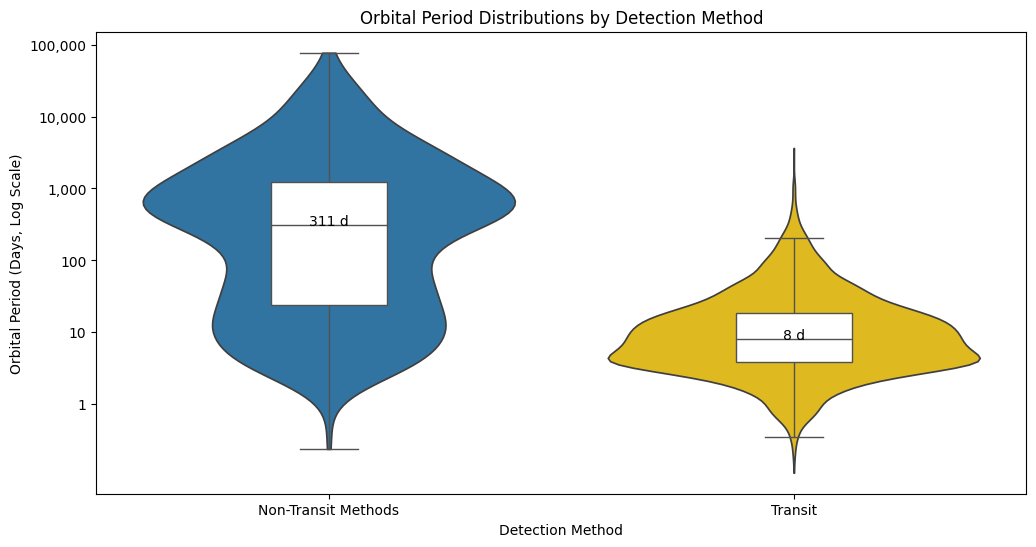

In [7]:
# Violin-Box Plot:
df_box = df_box.copy()

df_box["log_period"] = np.log10(df_box["period"])

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_box,
    x="method_group",
    y="log_period",
    inner=None,
    palette=palette,
    cut=0
)

ax = sns.boxplot(
    data=df_box,
    x="method_group",
    y="log_period",
    width=0.25,
    boxprops={'facecolor': 'white'},
    showfliers=False
)

ticks = np.arange(0, 6)

ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(10**t):,}" for t in ticks])

medians = df_box.groupby("method_group")["period"].median()

for i, median in enumerate(medians):
    ax.text(
        i, np.log10(median), f'{median:.0f} d', ha='center'
    )

plt.title("Orbital Period Distributions by Detection Method")
plt.xlabel("Detection Method")
plt.ylabel("Orbital Period (Days, Log Scale)")

plt.show()

# Violin-Box Plot Interpretation

## Orbital Period Distributions
The violin-box plot reveals a major difference between detection methods.

Transit discoveries are heavily concentrated at short orbital periods, with a median near 8 days.

In contrast, non-transit detections exhibit a much broader distribution with a substantially larger median orbital period, near 311 days.

This visual evidence strongly supports the statistical tests performed earlier and demonstrates how observational geometry biases transit surveys toward close-in planets.

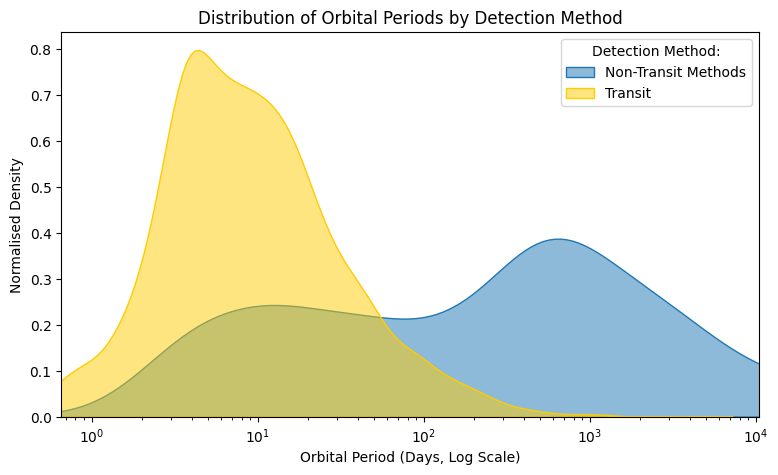

In [8]:
# Orbital Period KDE Plot:
plt.figure(figsize=(9, 5))

for method in df["method_group"].dropna().unique():

    subset = df[df["method_group"] == method]

    sns.kdeplot(
        data=subset,
        x="period",
        fill=True,
        log_scale=True,
        common_norm=False,
        color=palette.get(method, 'gray'),
        alpha=0.5,
        label=method
    )

lower = df["period"].quantile(0.01)
upper = df["period"].quantile(0.99)

plt.xlim(lower, upper)

plt.legend(title="Detection Method:")
plt.title("Distribution of Orbital Periods by Detection Method")
plt.xlabel("Orbital Period (Days, Log Scale)")
plt.ylabel("Normalised Density")

plt.show()

# KDE Interpretation

## Smoothed Orbital Period Density
Kernel density estimation (KDE) provides a smoother representation of the orbital-period distributions.

Transit detections form a sharp peak at short periods, while non-transit methods show a wider and more extended distribution.

The KDE plot reinforces the conclusion that detection methods probe different regions of exoplanet parameter space.

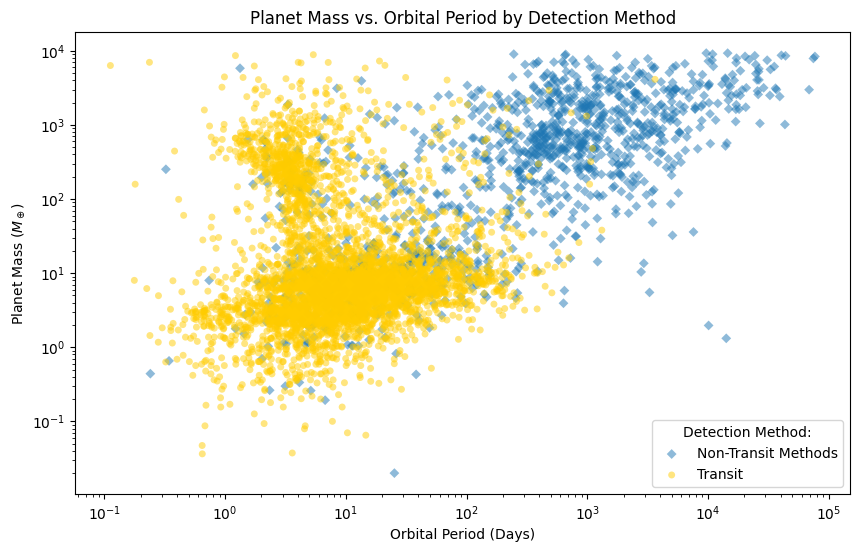

In [9]:
# Scatter Plot I:
plt.figure(figsize=(10, 6))

markers = {
    "Transit": "o",
    "Non-Transit Methods": "D"
}

for method in df["method_group"].unique():

    subset = df_scatter[
        df_scatter["method_group"] == method
    ]

    plt.scatter(
        subset["period"],
        subset["mass_earth"],
        label=method,
        color=palette.get(method, 'gray'),
        alpha=0.5,
        s=25,
        marker=markers.get(method, 'o'),
        edgecolors='none'
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Orbital Period (Days)")
plt.ylabel("Planet Mass ($M_\\oplus$)")

plt.title("Planet Mass vs. Orbital Period by Detection Method")

plt.legend(title="Detection Method:")

plt.show()

# Scatter Plot Interpretation

## Planet Mass and Orbital Period
The scatter distribution shows that low-mass planets are concentrated at shorter orbital periods.

At larger orbital distances, detected planets are increasingly dominated by high-mass systems.

This pattern reflects observational bias:

* Large planets generate stronger radial velocity signatures, and
* Close-in planets transit more frequently.

The absence of many low-mass long-period planets likely reflects detection limitations rather than their true rarity.

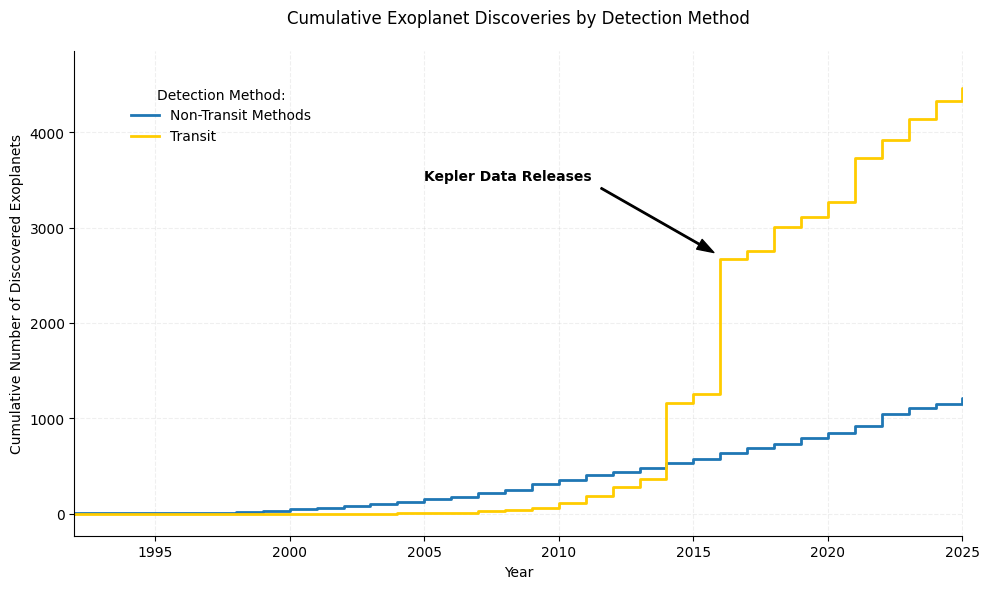

In [10]:
# Cumulative Step Plot:
global_start = df_time_series["year"].min()

plt.figure(figsize=(10, 6))

# Sort by Year:
df_time_series = df_time_series.sort_values("year")

# Plot Each Detection Method:
for method in df_time_series["method_group"].unique():

    subset = df_time_series[
        df_time_series["method_group"] == method
    ].copy()

    # Yearly Counts:
    yearly_counts = (
        subset
        .groupby("year")
        .size()
        .reset_index(name='count')
    )

    # Cumulative Counts:
    yearly_counts["cumulative"] = (
        yearly_counts["count"].cumsum()
    )

    # Create Baseline:
    first_year = yearly_counts["year"].min()

    baseline = pd.DataFrame({
        "year": [global_start, first_year],
        "cumulative": [0, 0]
    })

    final_subset = pd.concat([
        baseline,
        yearly_counts[["year", "cumulative"]]
    ])

    # Step Plot:
    plt.step(
        final_subset["year"],
        final_subset["cumulative"],
        where='post',
        label=method,
        color=palette.get(method, 'gray'),
        linewidth=2
    )

# Annotation
plt.annotate(
    'Kepler Data Releases',
    xy=(2016, 2700),
    xytext=(2005, 3500),
    arrowprops=dict(
        facecolor='black',
        shrink=0.05,
        width=1,
        headwidth=8
    ),
    fontsize=10,
    fontweight='bold'
)

# Styling
plt.xlim(global_start, 2025)

plt.xlabel("Year")

plt.ylabel("Cumulative Number of Discovered Exoplanets")

plt.title(
    "Cumulative Exoplanet Discoveries by Detection Method",
    pad=20
)

plt.legend(
    title="Detection Method:",
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(0.05, 0.95)
)

plt.grid(True, alpha=0.2, linestyle='--')

plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()

plt.show()

# Cumulative Steps Plot Interpretation

## Evolution of Exoplanet Discoveries Over Time
The cumulative discovery curves reveal a dramatic increase in exoplanet detections after the launch and data releases of the Kepler mission.

Transit discoveries accelerated rapidly during the 2010s and now dominate the confirmed exoplanet catalogue.

This demonstrates how technological developments and dedicated survey missions strongly shape astronomical datasets.

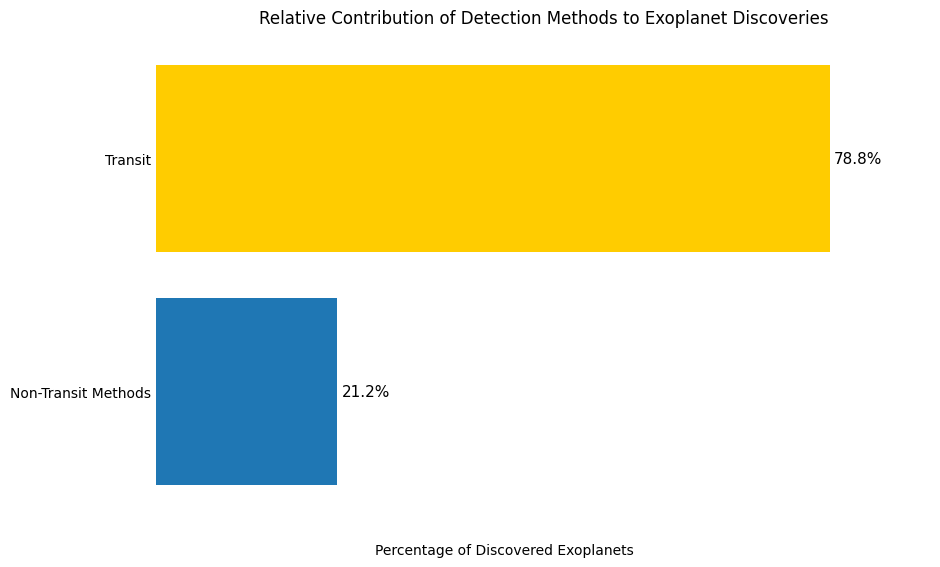

In [11]:
# Bar Chart:
method_counts = (
    df["method_group"]
    .value_counts(normalize=True) * 100
)

method_counts = method_counts.sort_values()

plt.figure(figsize=(10, 6))

colors = [
    palette.get(method, 'gray')
    for method in method_counts.index
]

bars = plt.barh(
    method_counts.index,
    method_counts.values,
    color=colors
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va='center',
        fontsize=11
    )

plt.xlabel(
    "Percentage of Discovered Exoplanets",
    labelpad=15
)

plt.ylabel("")

plt.xticks([])

plt.grid(False)

plt.tick_params(axis='y', length=0)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.xlim(0, method_counts.max() * 1.15)

plt.gca().xaxis.set_label_coords(0.45, -0.08)

plt.title(
    "Relative Contribution of Detection Methods to Exoplanet Discoveries",
    loc='center',
    pad=15
)

plt.show()

# Bar Chart Interpretation

## Relative Detection Contributions
Transit methods account for the overwhelming majority of confirmed exoplanet discoveries.

This dominance reflects the efficiency of large-scale photometric surveys such as Kepler and TESS (Transiting Exoplanet Survey Satellite).

However, the prevalence of transit detections also introduces strong observational biases into the known exoplanet population.

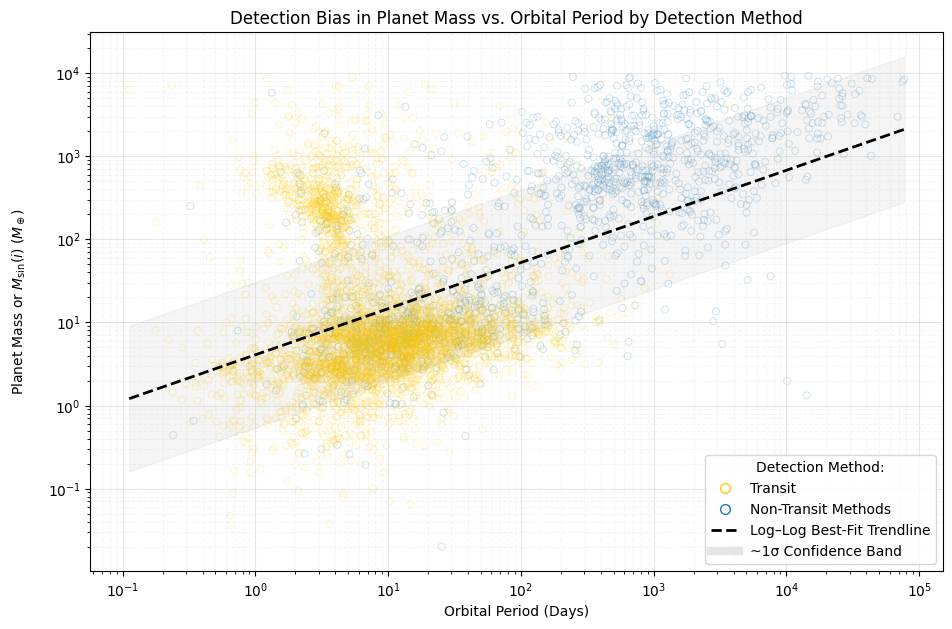

In [12]:
# Scatter Plot II + Trendline:
plt.figure(figsize=(11, 7))

for method in df_scatter["method_group"].unique():

    subset = df_scatter[
        df_scatter["method_group"] == method
    ]

    plt.scatter(
        subset["period"],
        subset["mass_earth"],
        color=palette.get(method, 'gray'),
        alpha=0.2,
        s=25,
        facecolors='none',
        edgecolors=palette.get(method, 'gray'),
        linewidth=0.7
    )

# Regression
log_x = np.log10(df_scatter["period"])
log_y = np.log10(df_scatter["mass_earth"])

coeffs = np.polyfit(log_x, log_y, 1)
poly = np.poly1d(coeffs)

x_vals = np.logspace(
    np.log10(df_scatter["period"].min()),
    np.log10(df_scatter["period"].max()),
    200
)

y_vals = 10**poly(np.log10(x_vals))

plt.plot(
    x_vals,
    y_vals,
    color='black',
    linewidth=2,
    linestyle='--',
    label='Log–Log Best-Fit Trendline'
)

# Confidence Band
residuals = log_y - poly(log_x)
std = np.std(residuals, ddof=1)

upper = 10**(
    poly(np.log10(x_vals)) + std
)

lower = 10**(
    poly(np.log10(x_vals)) - std
)

plt.fill_between(
    x_vals,
    lower,
    upper,
    color='grey',
    alpha=0.08,
    label='~1σ Confidence Band'
)

# Axes
plt.xscale('log')

plt.yscale('log')

plt.xlabel("Orbital Period (Days)")

plt.ylabel(
    "Planet Mass or $M_\\sin(i)$ ($M_\\oplus$)",
    labelpad=15
)

plt.title(
    "Detection Bias in Planet Mass vs. Orbital Period by Detection Method"
)

ax = plt.gca()

ax.xaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
)

ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
)

plt.grid(which='major', linestyle='-', alpha=0.3)
plt.grid(which='minor', linestyle='--', alpha=0.1)

legend_elements = [

    Line2D(
        [0],
        [0],
        marker='o',
        color='none',
        markeredgecolor=palette.get("Transit"),
        markerfacecolor='none',
        markersize=7,
        linewidth=0,
        label="Transit"
    ),

    Line2D(
        [0],
        [0],
        marker='o',
        color='none',
        markeredgecolor=palette.get("Non-Transit Methods"),
        markerfacecolor='none',
        markersize=7,
        linewidth=0,
        label="Non-Transit Methods"
    ),

    Line2D(
        [0],
        [0],
        color='black',
        linestyle='--',
        linewidth=2,
        label='Log–Log Best-Fit Trendline'
    ),

    Line2D(
        [0],
        [0],
        color='grey',
        linewidth=6,
        alpha=0.2,
        label='~1σ Confidence Band'
    )
]

plt.legend(
    handles=legend_elements,
    title="Detection Method:",
    frameon=True
)

plt.show()

# Trendline Scatter Interpretation

## Detection Bias in Mass–Period Space
The log–log trendline reveals a systematic relationship between planetary mass and orbital period within the detected sample.

The confidence band highlights the substantial spread in observed systems while still demonstrating an overall positive trend.

This distribution is shaped strongly by detection sensitivity:

* Small planets are difficult to detect at large distances from their host stars, while
* Large planets remain observable over broader orbital ranges.



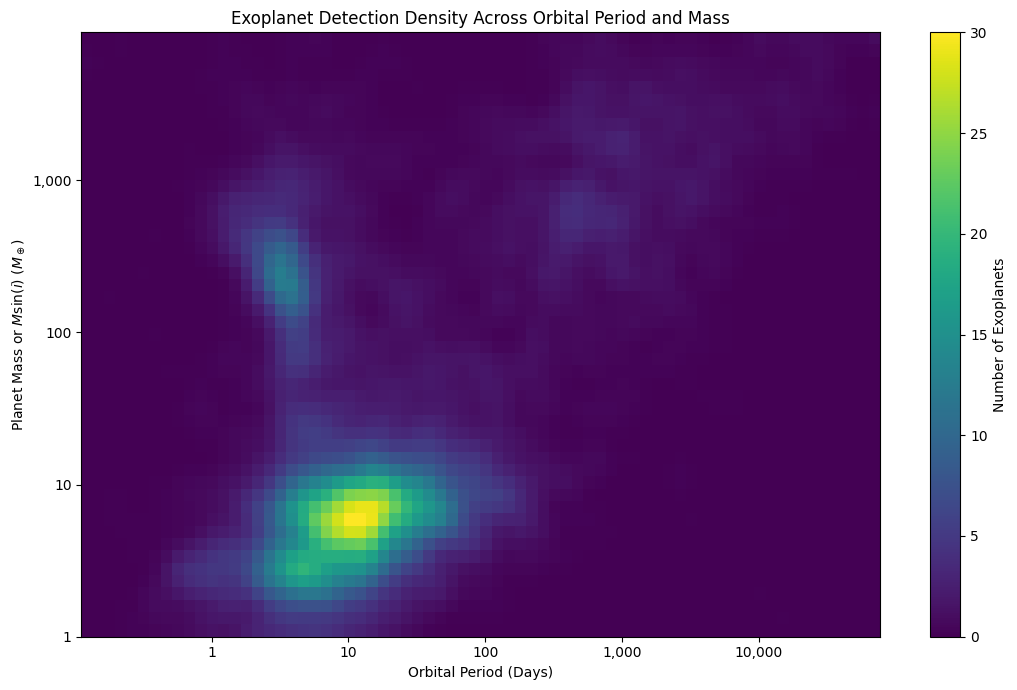

In [13]:
# Heatmap:
x_log = np.log10(df_scatter["period"])
y_log = np.log10(df_scatter["mass_earth"])

heatmap, xedges, yedges = np.histogram2d(
    x_log,
    y_log,
    bins=70
)

heatmap_smooth = gaussian_filter(
    heatmap,
    sigma=1.0
)

vmax = 30

plt.figure(figsize=(11, 7))

im = plt.imshow(
    heatmap_smooth.T,
    origin='lower',
    aspect='auto',
    extent=[
        xedges[0],
        xedges[-1],
        yedges[0],
        yedges[-1]
    ],
    cmap='viridis',
    vmin=0,
    vmax=vmax
)

cbar = plt.colorbar(im)
cbar.set_label("Number of Exoplanets")
cbar.set_ticks(np.arange(0, vmax + 1, 5))

def log_to_linear(val, pos):
    return f"{int(10**val):,}"

ax = plt.gca()
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

x_powers = np.arange(
    np.floor(x_min),
    np.ceil(x_max) + 1
)

y_powers = np.arange(
    np.floor(y_min),
    np.ceil(y_max) + 1
)

ax.xaxis.set_major_locator(
    FixedLocator(x_powers)
)

ax.yaxis.set_major_locator(
    FixedLocator(y_powers)
)

ax.xaxis.set_major_formatter(
    FuncFormatter(log_to_linear)
)

ax.yaxis.set_major_formatter(
    FuncFormatter(log_to_linear)
)

ax.set_ylim(bottom=np.log10(1))

plt.xlabel("Orbital Period (Days)")
plt.ylabel("Planet Mass or $M\\sin(i)$ ($M_\\oplus$)")

plt.title("Exoplanet Detection Density Across Orbital Period and Mass")

plt.tight_layout()

plt.show()

# Heatmap Interpretation

## Detection Density Across Parameter Space
The heatmap highlights where exoplanet detections are most concentrated.

The densest regions occur at:

* Short orbital periods, and
* Relatively moderate planetary masses.

Sparse regions at long periods and low masses likely reflect observational incompleteness rather than true absence of planets.

This figure visually demonstrates the regions of parameter space where current detection methods are most sensitive.

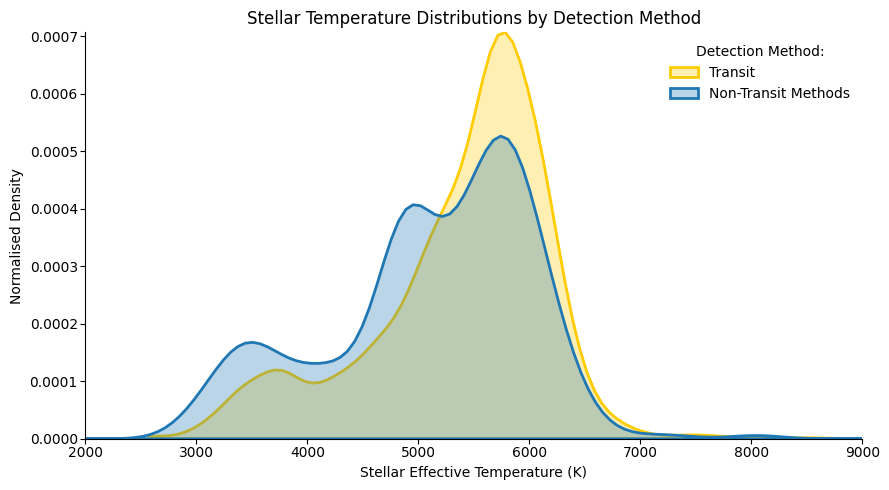

In [14]:
# Stellar Temperature KDE Plot:
plt.figure(figsize=(9, 5))

ax = plt.gca()

df_temp = df.dropna(
    subset=["stellar_temp", "method_group"]
).copy()

df_temp = df_temp[df_temp["stellar_temp"] > 0]

df_temp = df_temp[df_temp["stellar_temp"] < 20000]

df_transit = df_temp[
    df_temp["method_group"] == "Transit"
]

df_non_transit = df_temp[
    df_temp["method_group"] == "Non-Transit Methods"
]

sns.kdeplot(
    data=df_transit,
    x="stellar_temp",
    color=palette["Transit"],
    fill=True,
    alpha=0.3,
    linewidth=2,
    label="Transit",
    cut=0
)

sns.kdeplot(
    data=df_non_transit,
    x="stellar_temp",
    color=palette["Non-Transit Methods"],
    fill=True,
    alpha=0.3,
    linewidth=2,
    label="Non-Transit Methods",
    cut=0
)

plt.xlim(2000, 9000)

plt.xlabel("Stellar Effective Temperature (K)")
plt.ylabel("Normalised Density")

plt.title("Stellar Temperature Distributions by Detection Method")

ax.margins(x=0, y=0)

sns.despine(top=True, right=True)

ax.tick_params(axis='both', direction='out', pad=2)

plt.legend(
    title="Detection Method:",
    frameon=False
)

plt.tight_layout()

plt.show()

# Stellar Temperature Interpretation

## Stellar Temperature Distributions
Most of the confirmed exoplanets orbit stars with temperatures broadly similar to the Sun.

This reflects both astrophysical and observational factors:

* Sun-like stars are common, and
* They are favourable targets for many detection techniques.

Transit and non-transit detections show broadly similar stellar-temperature distributions, suggesting that stellar temperature is less strongly biased than orbital-period detection.

/tmp/ipykernel_9141/3394499236.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


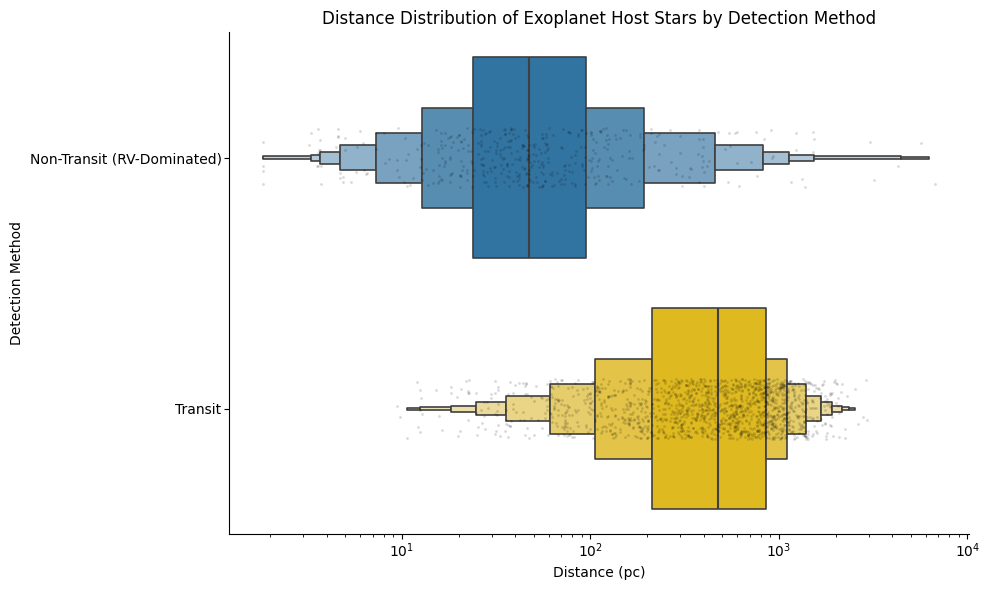

In [15]:
# Distance Boxen-Strip Plot:
plt.figure(figsize=(10, 6))

ax = plt.gca()

df_clean = df_distance.dropna(
    subset=["distance", "method_group"]
).copy()

df_clean["method_group_label"] = (
    df_clean["method_group"]
    .replace({
        "Non-Transit Methods": "Non-Transit (RV-Dominated)"
    })
)

palette_fixed = {
    "Transit": palette["Transit"],
    "Non-Transit (RV-Dominated)":
    palette["Non-Transit Methods"]
}

sns.boxenplot(
    data=df_clean,
    x="distance",
    y="method_group_label",
    palette=palette_fixed,
    linewidth=1.2,
    k_depth="proportion",
    showfliers=False
)

sampled = df_clean.sample(
    min(len(df_clean), 2000),
    random_state=42
)

sns.stripplot(
    data=sampled,
    x="distance",
    y="method_group_label",
    color='black',
    alpha=0.15,
    jitter=0.12,
    size=2
)

plt.xscale('log')

plt.title("Distance Distribution of Exoplanet Host Stars by Detection Method")

plt.xlabel("Distance (pc)")
plt.ylabel("Detection Method")

sns.despine(top=True, right=True)

ax.tick_params(axis='both', direction='out', pad=2)

plt.tight_layout()

plt.show()

# Distance Boxen-Strip Plot Interpretation

## Distance Bias in Detection Methods
Transit detections extend to substantially larger distances than non-transit methods.

This reflects the observational strategies of major transit surveys, which simultaneously monitor large stellar populations across distant regions of the galaxy.

Radial velocity detections remain concentrated around nearby stars because high-precision spectroscopic measurements become increasingly difficult for faint distant systems.

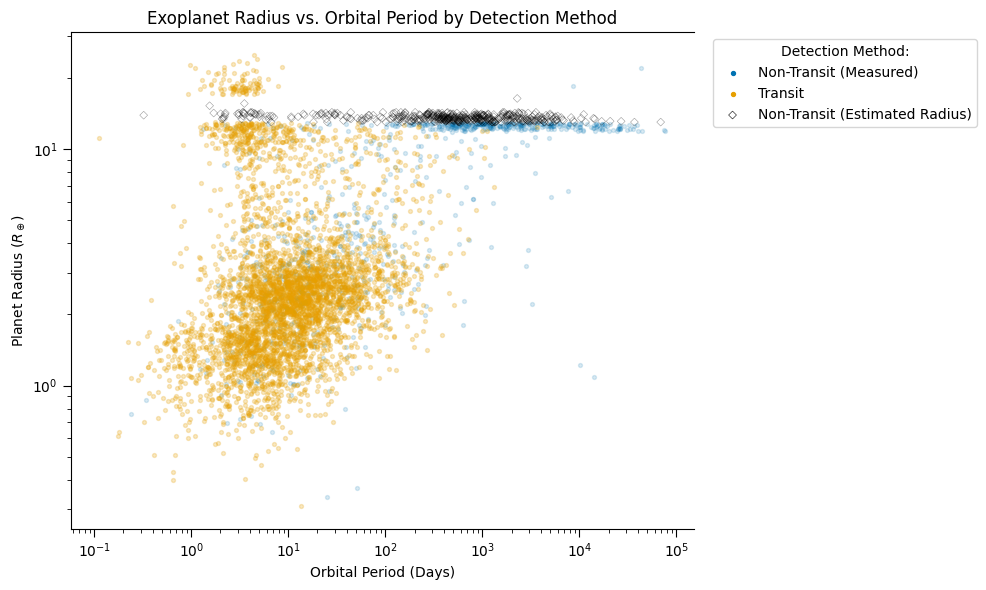

In [16]:
# Radius vs. Orbital Period Scatter Plot III:
plt.figure(figsize=(10, 6))

ax = plt.gca()

df_rad = df.dropna(
    subset=["period", "radius_earth", "method_group"]
).copy()

df_rad = df_rad[
    (df_rad["period"] > 0) &
    (df_rad["radius_earth"] > 0)
]

synthetic_mask = df_rad["radius_earth"].between(13, 17)

df_real = df_rad[~synthetic_mask]

df_synth = df_rad[synthetic_mask]

df_transit = df_real[
    df_real["method_group"] == "Transit"
]

df_non = df_real[
    df_real["method_group"] == "Non-Transit Methods"
]

df_synth_non = df_synth[
    df_synth["method_group"] == "Non-Transit Methods"
]

palette_improved = {
    "Transit": "#E69F00",
    "Non-Transit Methods": "#0072B2"
}

plt.scatter(
    df_non["period"],
    df_non["radius_earth"],
    s=8,
    alpha=0.15,
    color=palette_improved["Non-Transit Methods"],
    label="Non-Transit (Measured)",
    marker='o'
)

plt.scatter(
    df_transit["period"],
    df_transit["radius_earth"],
    s=8,
    alpha=0.24,
    color=palette_improved["Transit"],
    label="Transit",
    marker='o'
)

plt.scatter(
    df_synth_non["period"],
    df_synth_non["radius_earth"],
    s=16,
    facecolors='none',
    edgecolors='black',
    linewidths=0.4,
    alpha=0.4,
    label="Non-Transit (Estimated Radius)",
    marker='D'
)

plt.xscale('log')
plt.yscale('log')

ax.xaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
)

ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
)

ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(which='major', length=6)
ax.tick_params(which='minor', length=3)

plt.xlabel("Orbital Period (Days)")
plt.ylabel("Planet Radius ($R_\\oplus$)")

plt.title("Exoplanet Radius vs. Orbital Period by Detection Method")

leg = plt.legend(
    title="Detection Method:",
    frameon=True,
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

sns.despine(right=True, top=False)

ax.tick_params(axis='both', direction='out')

plt.tight_layout()

plt.show()

# Radius-Orbital Period Scatter Plot Intepretation

## Planet Radius and Orbital Period
Transit detections dominate the measured-radius population because planetary radii are directly observable during transits.

Non-transit systems contain fewer reliable radius measurements, and some large-radius values may represent model-derived estimates rather than direct observations.

The distribution further demonstrates that observational techniques determine which planetary properties can be measured accurately.

# Conclusion
This investigation showcased that the currently known exoplanet population is strongly shaped by observational selection effects.

Key findings include:

* Transit methods overwhelmingly dominate exoplanet discoveries
* Transit surveys preferentially detect short-period planets
* Long-period low-mass planets remain significantly under-detected
* Detection sensitivity strongly influences the observed mass–period distribution, and
* Distance and stellar properties further shape survey completeness.

These biases imply that the confirmed exoplanet catalogue is not yet a fully representative sample of planetary systems in the galaxy.

Future instruments and next-generation surveys will be required to prove the large population of currently undetectable Earth-like and long-period planets.